# Task 2: Credit Risk Prediction

## Introduction
Credit risk prediction helps banks and financial institutions identify loan applicants
who are likely to default on their loans.

## Dataset
Loan Prediction Dataset — contains applicant information such as income,
loan amount, credit history, and education level.

## Objective
Build a classification model to predict whether a loan applicant will default or not.

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [25]:
# Load dataset from local file
df = pd.read_csv('loan.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded!
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [26]:
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Column Names: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
 Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [27]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [28]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

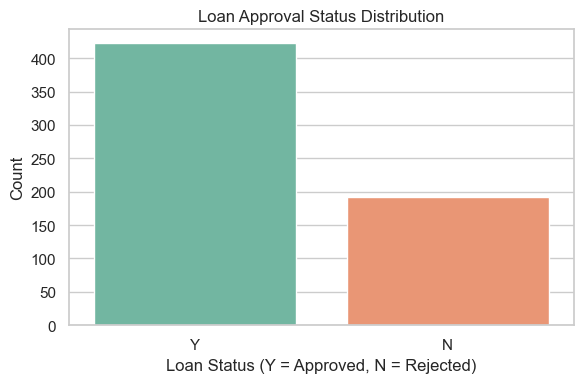

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', hue='Loan_Status', palette='Set2', legend=False)
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

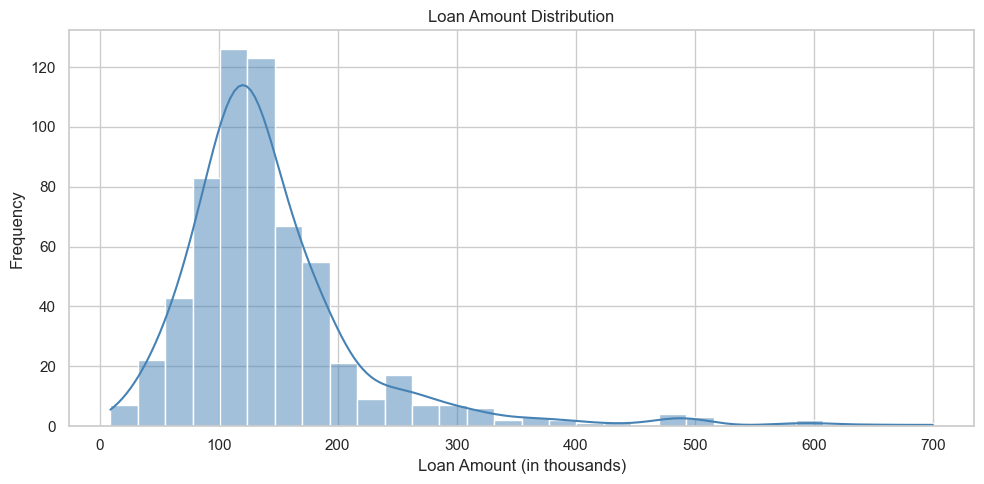

In [30]:
# Cell 7: Loan Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='steelblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount (in thousands)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

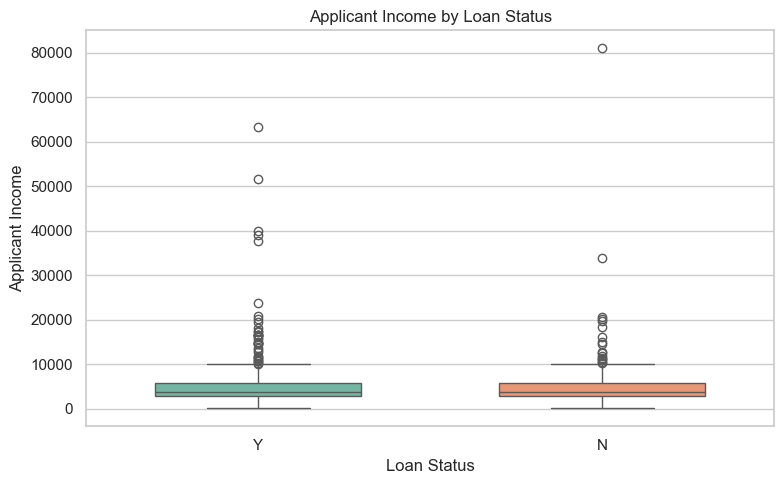

In [31]:
# Recommended Modern Version
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, 
            x='Loan_Status', 
            y='ApplicantIncome', 
            hue='Loan_Status',
            palette='Set2', 
            legend=False,
            width=0.6)
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.show()

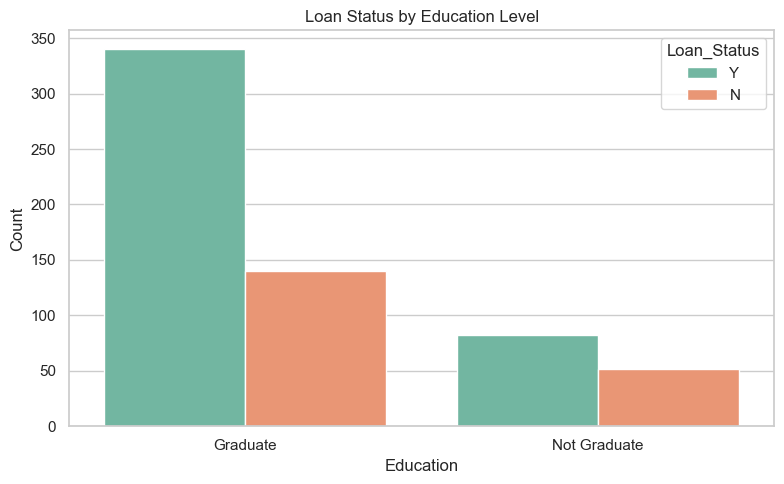

In [32]:
# Cell 9: Loan Status by Education Level
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Loan Status by Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [33]:
# Cell 10: Encode Categorical Features (Safe & Fixed Version)

# Safely drop Loan_ID only if it exists
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)
    print("✅ Loan_ID column dropped.")
else:
    print("ℹ️ Loan_ID column already dropped.")

# Encode target variable safely
if df['Loan_Status'].dtype == 'object' or df['Loan_Status'].dtype == 'string':
    df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
    print("✅ Loan_Status encoded (Y=1, N=0).")
else:
    print("ℹ️ Loan_Status already encoded.")

# Select categorical columns safely (Fixed pandas warning)
categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Label Encoding
le = LabelEncoder()
for col in categorical_features:
    df[col] = le.fit_transform(df[col])

print("\n✅ All categorical features encoded successfully!")
print(f"Encoded columns: {categorical_features}")
print(f"Final shape: {df.shape}")
df.head()

✅ Loan_ID column dropped.
✅ Loan_Status encoded (Y=1, N=0).

✅ All categorical features encoded successfully!
Encoded columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Final shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [34]:
# Cell 11: Prepare Data for Modeling

# Features and Target
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Target distribution in training: \n{y_train.value_counts(normalize=True)}")

Training samples: 491
Testing samples: 123
Target distribution in training: 
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


In [ ]:
# Cell 12: Train Logistic Regression (Simple Version)

#from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
#from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_preds = lr_model.predict(X_test_scaled)

# Evaluation
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_preds):.4f}")  # noqa: F821
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy : 0.8618
ROC-AUC  : 0.7836

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [37]:
# Cell 13: Train Decision Tree

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # Added max_depth to prevent overfitting
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)

# Evaluation
print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, dt_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, dt_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, dt_preds))

=== Decision Tree ===
Accuracy : 0.8211
ROC-AUC  : 0.7469

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.55      0.66        38
           1       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



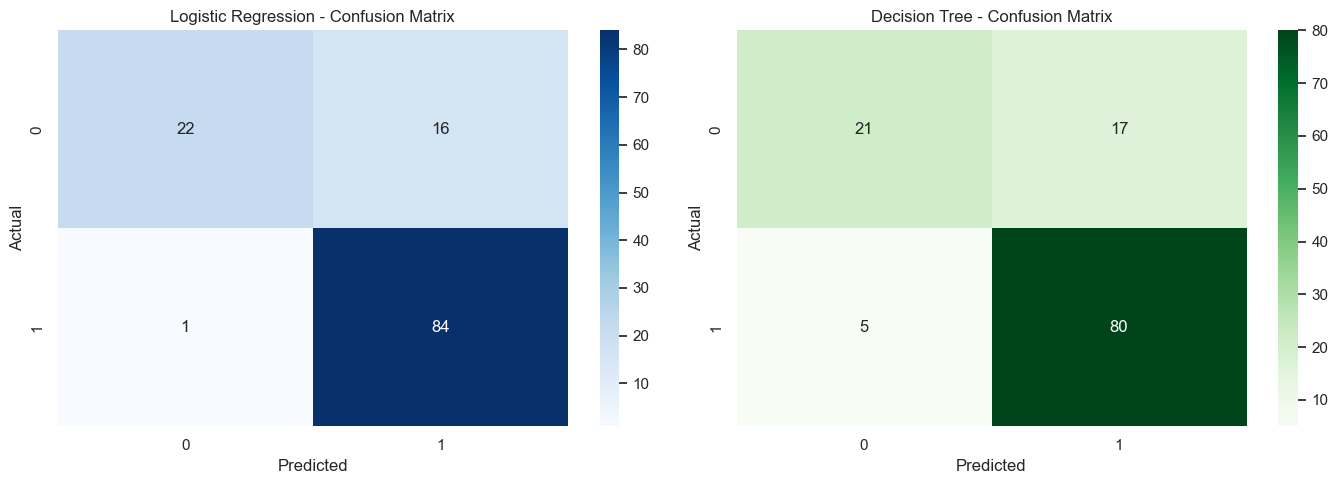

In [38]:
# Cell 14: Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', 
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', 
            cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Conclusion

- The dataset had missing values which were handled using **mode** for categorical
  and **median** for numerical columns.
- **Credit History** turned out to be the most influential feature for loan approval.
- **Logistic Regression** performed better than Decision Tree on this dataset.
- Applicants with good credit history and higher income were more likely to get approved.
- This model can help banks automate and speed up the loan approval process.

